Chart 1 — Bar: "Which countries are happiest right now?"


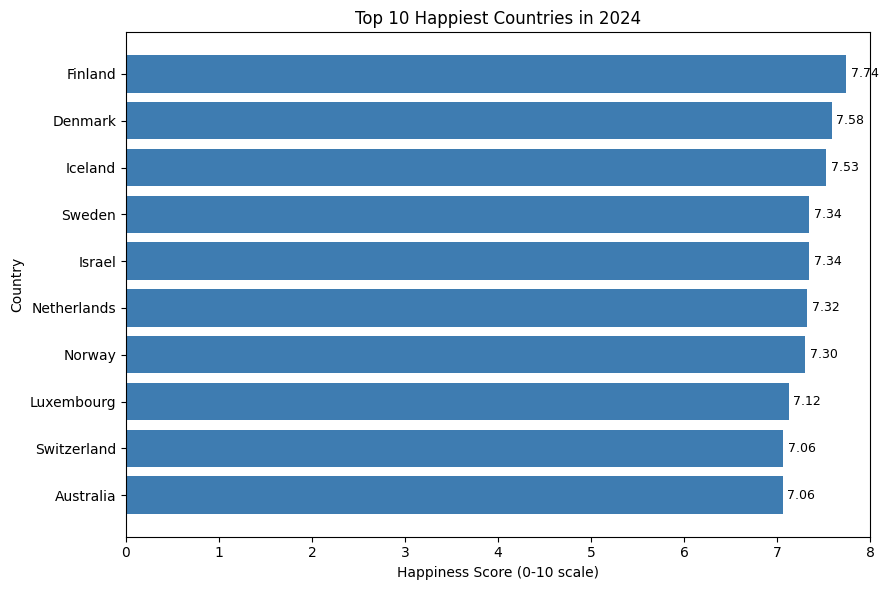

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('happiness_cleaned.xlsx')   # upload the file to Colab first
latest = df[df['Year'] == 2024].sort_values('Happiness score', ascending=False)
top10 = latest.head(10)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top10['Country name'][::-1], top10['Happiness score'][::-1], color='#3E7CB1')
ax.set_xlabel('Happiness Score (0-10 scale)')
ax.set_ylabel('Country')
ax.set_title('Top 10 Happiest Countries in 2024')
ax.set_xlim(0, 8)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.05, bar.get_y() + bar.get_height()/2, f'{w:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_bar_top10.png', dpi=150)
plt.show()

Takeaway: Finland leads the 2024 rankings at 7.74, with Nordic and Western European countries dominating the top 10.

Why bar here: the question compares discrete categories (countries) at one point in time — bar charts are for comparing magnitudes across categories, not for showing change over a continuum.

Chart 2 — Line: "How has global happiness changed over time?"

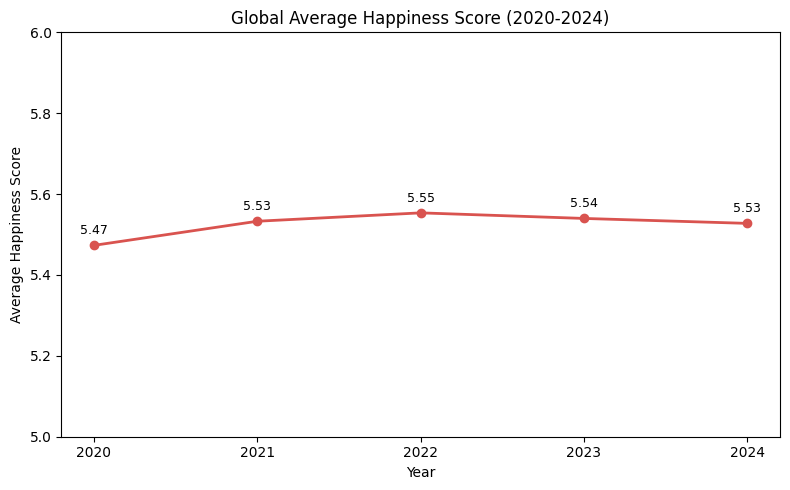

In [ ]:
trend = df.groupby('Year')['Happiness score'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(trend.index, trend.values, marker='o', color='#D9534F', linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('Average Happiness Score')
ax.set_title('Global Average Happiness Score (2020-2024)')
ax.set_xticks(trend.index)
ax.set_ylim(5.0, 6.0)
for x, y in zip(trend.index, trend.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart2_line_trend.png', dpi=150)
plt.show()

Takeaway: Global average happiness rose slightly after 2020 (5.47 → 5.55 in 2022) then plateaued, staying essentially flat through 2024 (5.53).

Why line here: the question is about change across a continuous sequence (years) — line charts show trend and direction, which a bar chart would obscure.

Chart 3 — Pie: "What share of countries fall into each happiness category?"

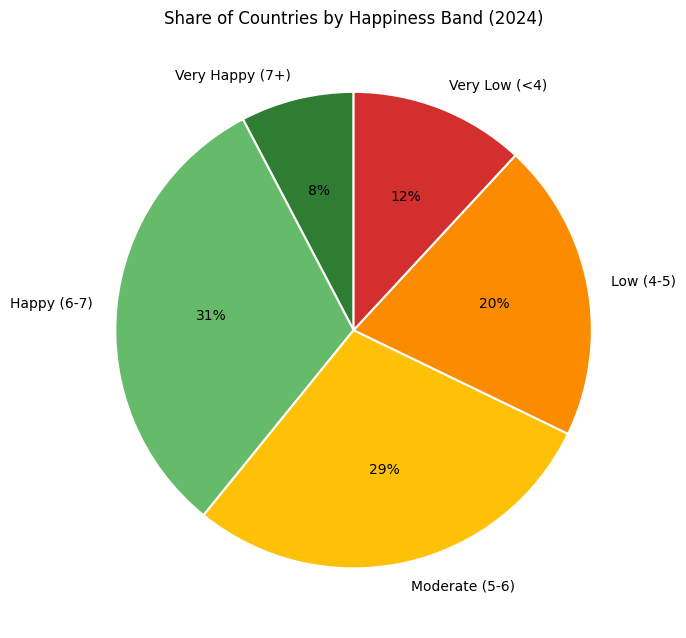

In [ ]:
def band(x):
    if x >= 7: return 'Very Happy (7+)'
    elif x >= 6: return 'Happy (6-7)'
    elif x >= 5: return 'Moderate (5-6)'
    elif x >= 4: return 'Low (4-5)'
    else: return 'Very Low (<4)'

latest['band'] = latest['Happiness score'].apply(band)
order = ['Very Happy (7+)', 'Happy (6-7)', 'Moderate (5-6)', 'Low (4-5)', 'Very Low (<4)']
counts = latest['band'].value_counts().reindex(order)
colors = ['#2E7D32', '#66BB6A', '#FFC107', '#FB8C00', '#D32F2F']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts.values, labels=counts.index, autopct='%1.0f%%', colors=colors,
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Share of Countries by Happiness Band (2024)')
plt.tight_layout()
plt.savefig('chart3_pie_bands.png', dpi=150)
plt.show()

Takeaway: Only 8% of countries reach the "Very Happy" band, while 32% sit in the Low/Very Low bands — global happiness is unevenly distributed and skewed toward the middle.

Why pie here: the question is about parts of a whole (5 mutually exclusive groups summing to 100%) — exactly the case a pie chart is meant for, and it stays under the 5-slice limit.

Chart 4 — Bar: "Does economic strength track with happiness?"

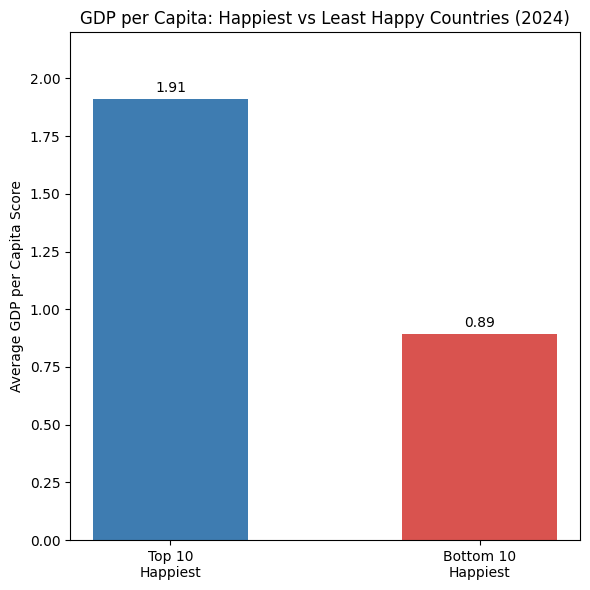

In [ ]:
bottom10 = latest.tail(10)
groups = ['Top 10\nHappiest', 'Bottom 10\nHappiest']
gdp_vals = [top10['Economy (GDP per Capita)'].mean(), bottom10['Economy (GDP per Capita)'].mean()]

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(groups, gdp_vals, color=['#3E7CB1', '#D9534F'], width=0.5)
ax.set_ylabel('Average GDP per Capita Score')
ax.set_title('GDP per Capita: Happiest vs Least Happy Countries (2024)')
ax.set_ylim(0, 2.2)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f'{h:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart4_bar_gdp_compare.png', dpi=150)
plt.show()

Takeaway: The 10 happiest countries have more than double the average GDP-per-capita score of the 10 least happy (1.91 vs 0.89), suggesting wealth is strongly associated with — but not the sole driver of — happiness.